In [8]:
import pandas as pd

# Load CSV file
df = pd.read_csv(r'C:\Users\bntmm\Desktop\GRIFOLS\BioPredict-Data-Driven-Modeling-of-Serological-Markers\notebooks\data\hepatitis_b_optuna_model_predictions.csv')

# Sort by a column (replace 'column_name' with the actual column name)
df_sorted = df.sort_values('Predicted_Score_Class_1', ascending=False)

df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1653 entries, 682 to 115
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sample_Index             1653 non-null   int64  
 1   Actual_Label             1653 non-null   int64  
 2   Predicted_Label          1653 non-null   int64  
 3   Predicted_Score_Class_0  1653 non-null   float64
 4   Predicted_Score_Class_1  1653 non-null   float64
 5   Prediction_Confidence    1653 non-null   float64
 6   Correct_Prediction       1653 non-null   int64  
 7   Model_Type               1653 non-null   object 
 8   Class_0_Label            1653 non-null   object 
 9   Class_1_Label            1653 non-null   object 
 10  Feature_Gender           1653 non-null   int64  
 11  Feature_Age              1653 non-null   int64  
 12  Feature_Race_Ethnicity   1653 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 180.8+ KB


In [2]:
df_sorted[0:50]

,Sample_Index,Actual_Label,Predicted_Label,Predicted_Score_Class_0,Predicted_Score_Class_1,Prediction_Confidence,Correct_Prediction,Model_Type,Class_0_Label,Class_1_Label,Feature_Gender,Feature_Age,Feature_Race_Ethnicity
682,2468,1,1,0.295355,0.704645,0.704645,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,2,3,5
1258,6873,1,1,0.295355,0.704645,0.704645,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,2,3,5
842,5077,0,1,0.306714,0.693287,0.693287,0,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,2,5
744,6232,1,1,0.306714,0.693287,0.693287,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,2,5
416,4929,1,1,0.306714,0.693287,0.693287,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,2,5
66,955,1,1,0.306714,0.693287,0.693287,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,2,5
1646,3177,0,1,0.307665,0.692335,0.692335,0,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,2,5,5
118,8195,1,1,0.317755,0.682245,0.682245,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,3,5
297,2363,1,1,0.317755,0.682245,0.682245,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,3,5
471,6345,1,1,0.317755,0.682245,0.682245,1,Optuna_Optimized_XGBoost,No_Hepatitis_B,Hepatitis_B,1,3,5


--- Tabla de Ganancias por Decil (Modelo Optuna XGBoost) ---
        total_in_decile  positives_found  cumulative_positives  \
decile                                                           
1                   166              110                   110   
2                   165              100                   210   
3                   165               75                   285   
4                   165               59                   344   
5                   166               54                   398   
6                   165               41                   439   
7                   165               30                   469   
8                   165               31                   500   
9                   165               17                   517   
10                  166               11                   528   

        cumulative_gain_percentage  percentage_population_targeted  \
decile                                                               
1     

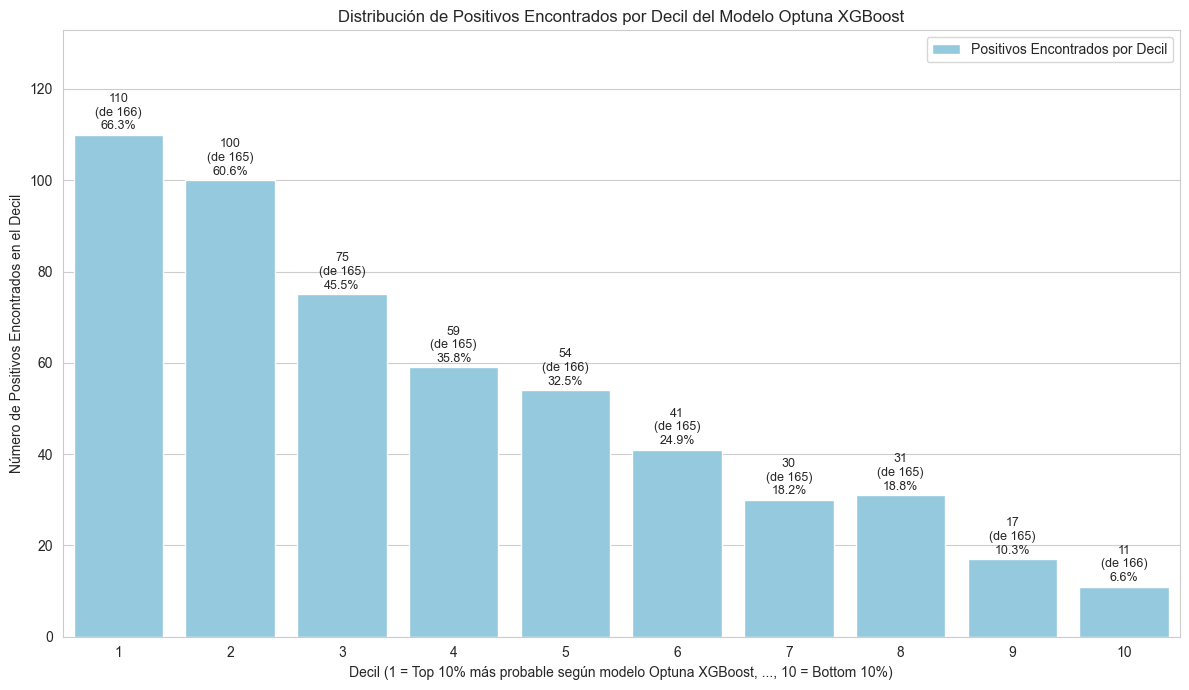

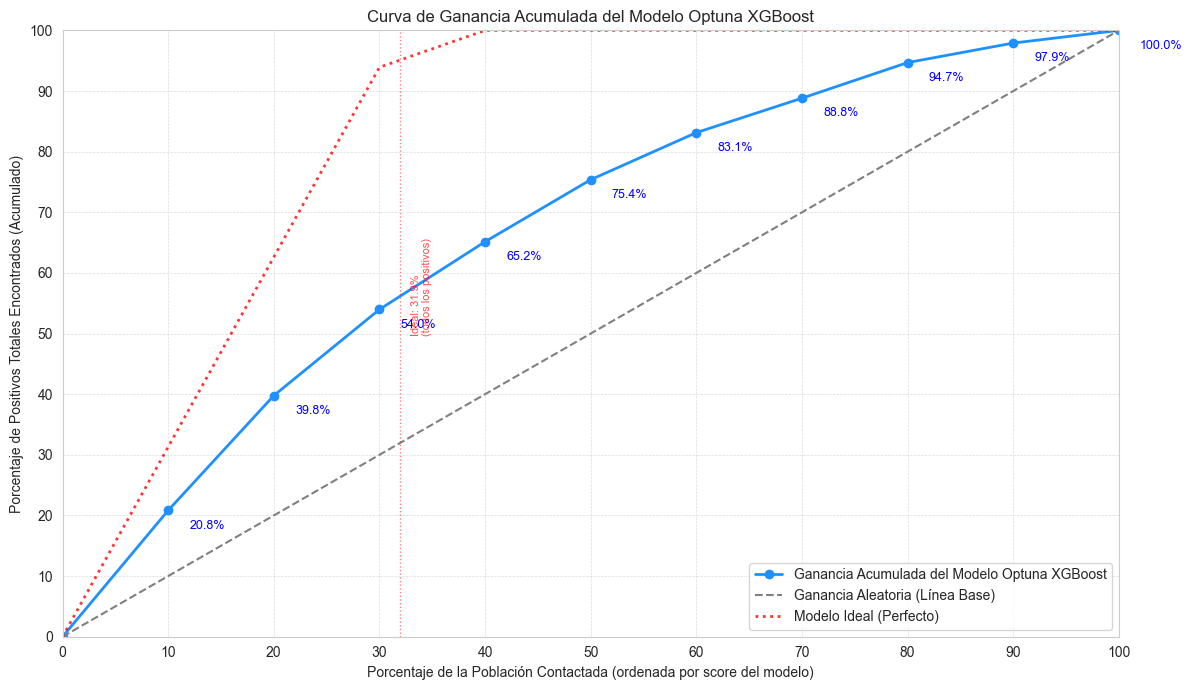


--- Interpretación para Negocio (Modelo Optuna XGBoost) ---

📊 COMPARACIÓN CON MODELO IDEAL:
   • Modelo Ideal capturaría 100% de positivos contactando solo al 31.9% de la población
   • Tu modelo Optuna XGBoost necesita contactar más población para capturar el mismo % de positivos
   • La diferencia entre tu curva azul y la línea roja punteada muestra el margen de mejora

📈 PERFORMANCE DEL MODELO OPTUNA:
   • Accuracy: 0.732
   • Total de muestras: 1653
   • Casos positivos: 528
   • Tasa base: 31.94%

Para encontrar aproximadamente el 39.8% de todos los positivos (210 de 528):
  - Necesitamos contactar al 20% de la población mejor puntuada por el modelo.
  - Esto corresponde a los primeros 2 deciles, que son 331 individuos.
  - Sin el modelo (aleatoriamente), para encontrar el 30% de los positivos, esperaríamos tener que contactar al 30% de la población total (495 individuos).
  - El modelo es aproximadamente 1.50 veces más eficiente para alcanzar este objetivo que la selección alea

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar los datos del CSV
try:
    df = pd.read_csv('hepatitis_b_optuna_model_predictions.csv')
except FileNotFoundError:
    print("Error: 'hepatitis_b_optuna_model_predictions.csv' no encontrado.")
    exit()

# Verificar columnas correctas - ADAPTADO PARA EL NUEVO CSV
required_cols = ['Actual_Label', 'Predicted_Score_Class_1']
if not all(col in df.columns for col in required_cols):
    print(f"Error: El CSV debe contener las columnas: {', '.join(required_cols)}")
    print(f"Columnas disponibles: {df.columns.tolist()}")
    exit()

# 2. Ordenar por Predicted_Score_Class_1 (probabilidad de Hepatitis_B = 1)
df_sorted = df.sort_values(by='Predicted_Score_Class_1', ascending=False).reset_index(drop=True)

# 3. Crear deciles
try:
    df_sorted['decile'] = pd.qcut(df_sorted.index, 10, labels=False) + 1
except ValueError as e:
    # Manejo de error como en tu código original
    print(f"Advertencia: {e}")
    n_rows = len(df_sorted)
    rows_per_decile = n_rows // 10
    if rows_per_decile == 0:
        print("Error: Datos insuficientes para 10 deciles.")
        exit()
    
    decile_assignments = []
    for i in range(10):
        decile_assignments.extend([i + 1] * rows_per_decile)
    
    remaining = n_rows % 10
    if remaining > 0:
        decile_assignments.extend([10] * remaining)
    df_sorted['decile'] = decile_assignments[:n_rows]

# 4. Calcular métricas por decil - ADAPTADO PARA EL NUEVO CSV
count_per_decile = df_sorted.groupby('decile').size().rename('total_in_decile')

# Usar 'Actual_Label' en lugar de 'Hepatitis_B'
positives_per_decile = df_sorted[df_sorted['Actual_Label'] == 1.0].groupby('decile').size().rename('positives_found')

gains_table = pd.concat([count_per_decile, positives_per_decile], axis=1).fillna(0)
gains_table['positives_found'] = gains_table['positives_found'].astype(int)

# 5. Métricas acumulativas
gains_table['cumulative_positives'] = gains_table['positives_found'].cumsum()
total_positives_in_dataset = df_sorted['Actual_Label'].sum()  # Adaptado

if total_positives_in_dataset == 0:
    print("Advertencia: No hay positivos en el dataset.")
    gains_table['cumulative_gain_percentage'] = 0.0
else:
    gains_table['cumulative_gain_percentage'] = (gains_table['cumulative_positives'] / total_positives_in_dataset) * 100

gains_table['percentage_population_targeted'] = np.arange(1, 11) * 10
gains_table['positive_rate_in_decile (%)'] = (gains_table['positives_found'] / gains_table['total_in_decile'] * 100).round(2)

# --- Calcular línea ideal ---
total_population = len(df_sorted)
ideal_cutoff_pct = (total_positives_in_dataset / total_population) * 100

ideal_x = [0]
ideal_y = [0]

if total_positives_in_dataset > 0:
    for pct in range(10, 101, 10):
        if pct <= ideal_cutoff_pct:
            ideal_gain = (pct / ideal_cutoff_pct) * 100
        else:
            ideal_gain = 100
        
        ideal_x.append(pct)
        ideal_y.append(min(ideal_gain, 100))

# --- Impresión de la Tabla de Ganancias Detallada ---
print("--- Tabla de Ganancias por Decil (Modelo Optuna XGBoost) ---")
print(gains_table)
print(f"\nTotal de individuos en el dataset: {len(df_sorted)}")
print(f"Total de positivos (objetivo) en el dataset: {int(total_positives_in_dataset)}")
if total_positives_in_dataset > 0:
    print(f"Tasa base de positivos (aleatoria): {total_positives_in_dataset/len(df_sorted)*100:.2f}%")
print("------------------------------------")

# --- Visualización ---
sns.set_style("whitegrid")

# Gráfico 1: Número de Positivos Encontrados por Decil (Barras)
plt.figure(figsize=(12, 7))
ax1 = sns.barplot(x=gains_table.index, y='positives_found', data=gains_table, color='skyblue', label='Positivos Encontrados por Decil')
plt.xlabel("Decil (1 = Top 10% más probable según modelo Optuna XGBoost, ..., 10 = Bottom 10%)")
plt.ylabel("Número de Positivos Encontrados en el Decil")
plt.title("Distribución de Positivos Encontrados por Decil del Modelo Optuna XGBoost")

# Añadir etiquetas de texto a las barras
for i, bar in enumerate(ax1.patches):
    height = bar.get_height()
    total_in_dec = gains_table['total_in_decile'].iloc[i]
    positive_rate = gains_table['positive_rate_in_decile (%)'].iloc[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{int(height)}\n(de {total_in_dec})\n{positive_rate:.1f}%",
        ha='center', va='bottom', fontsize=9
    )
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.15)
plt.legend()
plt.tight_layout()
plt.show()

# Gráfico 2: Curva de Ganancia Acumulada con Línea Ideal - CORREGIDO
plt.figure(figsize=(12, 7))

# CORRECCIÓN: Añadir el punto inicial (0,0) a la curva del modelo
model_x = [0] + list(gains_table['percentage_population_targeted'])
model_y = [0] + list(gains_table['cumulative_gain_percentage'])

# Línea del modelo - CORREGIDA
plt.plot(model_x, model_y, 
         marker='o', linestyle='-', color='dodgerblue', linewidth=2, 
         label='Ganancia Acumulada del Modelo Optuna XGBoost')

# Línea base (aleatoria)
plt.plot([0] + list(gains_table['percentage_population_targeted']), 
         [0] + list(gains_table['percentage_population_targeted']), 
         linestyle='--', color='gray', linewidth=1.5,
         label='Ganancia Aleatoria (Línea Base)')

# Línea ideal (modelo perfecto)
plt.plot(ideal_x, ideal_y, 
         linestyle=':', color='red', linewidth=2, 
         label='Modelo Ideal (Perfecto)', alpha=0.8)

plt.xlabel("Porcentaje de la Población Contactada (ordenada por score del modelo)")
plt.ylabel("Porcentaje de Positivos Totales Encontrados (Acumulado)")
plt.title("Curva de Ganancia Acumulada del Modelo Optuna XGBoost")
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Añadir puntos de datos a la curva del modelo - AJUSTADO
for i, row in gains_table.iterrows():
    plt.text(row['percentage_population_targeted'] + 2, row['cumulative_gain_percentage'] - 3,
             f"{row['cumulative_gain_percentage']:.1f}%",
             fontsize=9, color='blue')

# Línea vertical para el punto de corte ideal
if total_positives_in_dataset > 0:
    plt.axvline(x=ideal_cutoff_pct, color='red', linestyle=':', alpha=0.5, linewidth=1)
    plt.text(ideal_cutoff_pct + 1, 50, 
             f'Ideal: {ideal_cutoff_pct:.1f}%\n(todos los positivos)', 
             rotation=90, fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.show()

# --- Interpretación de Negocio ---
print("\n--- Interpretación para Negocio (Modelo Optuna XGBoost) ---")
if total_positives_in_dataset == 0:
    print("No hay positivos en los datos, la interpretación del Gains Chart no es aplicable.")
else:
    print(f"\n📊 COMPARACIÓN CON MODELO IDEAL:")
    print(f"   • Modelo Ideal capturaría 100% de positivos contactando solo al {ideal_cutoff_pct:.1f}% de la población")
    print(f"   • Tu modelo Optuna XGBoost necesita contactar más población para capturar el mismo % de positivos")
    print(f"   • La diferencia entre tu curva azul y la línea roja punteada muestra el margen de mejora")
    
    # Análisis de performance del modelo
    accuracy = (df['Actual_Label'] == df['Predicted_Label']).mean()
    print(f"\n📈 PERFORMANCE DEL MODELO OPTUNA:")
    print(f"   • Accuracy: {accuracy:.3f}")
    print(f"   • Total de muestras: {len(df)}")
    print(f"   • Casos positivos: {int(total_positives_in_dataset)}")
    print(f"   • Tasa base: {total_positives_in_dataset/len(df_sorted)*100:.2f}%")
    
    try:
        target_gain_pct = 30
        deciles_to_reach_target = gains_table[gains_table['cumulative_gain_percentage'] >= target_gain_pct].index[0]
        population_pct_for_target = gains_table.loc[deciles_to_reach_target, 'percentage_population_targeted']
        positives_at_target_decile = gains_table.loc[deciles_to_reach_target, 'cumulative_positives']
        total_contacted_for_target = gains_table.loc[:deciles_to_reach_target, 'total_in_decile'].sum()

        print(f"\nPara encontrar aproximadamente el {positives_at_target_decile / total_positives_in_dataset * 100:.1f}% de todos los positivos ({int(positives_at_target_decile)} de {int(total_positives_in_dataset)}):")
        print(f"  - Necesitamos contactar al {population_pct_for_target}% de la población mejor puntuada por el modelo.")
        print(f"  - Esto corresponde a los primeros {deciles_to_reach_target} deciles, que son {total_contacted_for_target} individuos.")
        print(f"  - Sin el modelo (aleatoriamente), para encontrar el {target_gain_pct}% de los positivos, esperaríamos tener que contactar al {target_gain_pct}% de la población total ({int(len(df_sorted) * target_gain_pct / 100)} individuos).")
        if int(len(df_sorted) * target_gain_pct / 100) > 0:
            efficiency_gain = (int(len(df_sorted) * target_gain_pct / 100)) / total_contacted_for_target
            print(f"  - El modelo es aproximadamente {efficiency_gain:.2f} veces más eficiente para alcanzar este objetivo que la selección aleatoria.")

        # Análisis específico para Hepatitis B
        target_N_pacientes = 100  # Ajustado a un número más realista para el dataset
        if target_N_pacientes > total_positives_in_dataset:
            print(f"\nADVERTENCIA: El objetivo de {target_N_pacientes} pacientes es mayor que el total de positivos ({int(total_positives_in_dataset)}) en este dataset de prueba.")
            target_N_pacientes_adjusted = int(total_positives_in_dataset)
        else:
            target_N_pacientes_adjusted = target_N_pacientes

        if target_N_pacientes_adjusted > 0:
            deciles_to_reach_N_pacientes = gains_table[gains_table['cumulative_positives'] >= target_N_pacientes_adjusted].index[0]
            total_contacted_for_N = gains_table.loc[:deciles_to_reach_N_pacientes, 'total_in_decile'].sum()
            found_at_N_deciles = gains_table.loc[deciles_to_reach_N_pacientes, 'cumulative_positives']

            print(f"\nPara encontrar aproximadamente {int(found_at_N_deciles)} pacientes con Hepatitis B (lo más cercano a {target_N_pacientes_adjusted}):")
            print(f"  - Necesitamos contactar a los primeros {deciles_to_reach_N_pacientes} deciles, que son {total_contacted_for_N} individuos.")

            if found_at_N_deciles > 0:
                random_contact_needed = int(round((found_at_N_deciles / total_positives_in_dataset) * len(df_sorted))) if total_positives_in_dataset > 0 else len(df_sorted)
                print(f"  - Aleatoriamente, para encontrar {int(found_at_N_deciles)} pacientes, se esperaría contactar a unos {random_contact_needed} individuos.")
                if total_contacted_for_N > 0:
                    print(f"  - El modelo requiere contactar {random_contact_needed - total_contacted_for_N} menos individuos (es {random_contact_needed / total_contacted_for_N:.2f} veces más eficiente).")
    
    except IndexError:
        print("No se pudieron calcular las métricas de negocio debido a insuficientes datos o deciles.")
    except Exception as e:
        print(f"Error en el cálculo de interpretación de negocio: {e}")

# Mostrar información adicional del modelo Optuna
print(f"\n🔬 INFORMACIÓN DEL MODELO:")
print(f"   • Tipo de modelo: {df['Model_Type'].iloc[0]}")
print(f"   • Optimización: Hyperparameter tuning con Optuna")
print(f"   • Target: Hepatitis B detection")
print(f"   • Algoritmo base: XGBoost")